# EDA — Caso 3: Revisión de Compensaciones por Posible Fraude

**Proyecto:** Agente de decisión para compensaciones CX (Rappi).

**Dataset:** `data/Dataset_caso_3.xlsx` → pestaña `Caso3_Compensaciones` (150 casos).

**Objetivo de este notebook:** entender distribuciones, outliers, correlaciones y patrones de negocio que alimenten el *feature engineering* (step 02) y las **reglas heurísticas** de fraude (step 03). No se entrena ningún modelo ML: el dataset es pequeño (150 casos) y la decisión se basará en reglas documentadas.

## Outline

1. Configuración e imports
2. Carga del dataset
3. Vista general (shape, tipos, nulos)
4. Estadísticos descriptivos y percentiles clave
5. Distribuciones de variables numéricas
6. Correlaciones
7. Patrones de negocio
   - 7.1 Geografía y vertical
   - 7.2 Restaurantes con más reclamos
   - 7.3 Antigüedad del usuario
   - 7.4 GPS vs frecuencia de reclamos
8. Conclusiones: señales candidatas para el motor de reglas

## 1. Configuración e imports

Solo librerías estándar de análisis: `pandas` para datos, `matplotlib`/`seaborn` para visualización. Los gráficos se muestran **inline**; no se exportan archivos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

## 2. Carga del dataset

El Excel tiene una **fila de título decorativa** en la fila 0, por lo que los encabezados reales están en la fila 1 (`header=1`).

La ruta se resuelve de forma robusta para que el notebook funcione tanto si se ejecuta desde la raíz del proyecto como desde `notebooks/`.

In [2]:
CANDIDATAS = [
    Path('data/Dataset_caso_3.xlsx'),
    Path('../data/Dataset_caso_3.xlsx'),
]
EXCEL_PATH = next((p for p in CANDIDATAS if p.exists()), None)
assert EXCEL_PATH is not None, 'No se encontró data/Dataset_caso_3.xlsx'

df = pd.read_excel(EXCEL_PATH, sheet_name='Caso3_Compensaciones', header=1)
df.head()

,caso_id,usuario_id,antiguedad_usuario_dias,ciudad,vertical,restaurante,valor_orden_mxn,compensacion_solicitada_mxn,num_compensaciones_90d,monto_compensado_90d_mxn,entrega_confirmada_gps,tiempo_entrega_real_min,flags_fraude_previos,motivo_reclamo,descripcion_reclamo,recomendacion_agente
0,COMP-0001,USR-11567,1590,CDMX,Comida,La Cocina de Doña Rosa,668.79,423.76,2,103.53,NO confirmada,56,0,Producto incorrecto,"Llegó comida diferente, creo que confundieron ...",PENDIENTE
1,COMP-0002,maximosabor,229,Bogotá,Mercado,El Rincón Colombiano,166.56,153.91,2,334.39,Parcial,60,1,Producto incorrecto,Me mandaron una hamburguesa con queso y tengo ...,PENDIENTE
2,COMP-0003,USR-13864,200,Buenos Aires,Mercado,La Cocina de Doña Rosa,226.34,203.15,2,691.29,NO confirmada,53,1,Producto incompleto,No incluyeron las salsas ni los cubiertos.,PENDIENTE
3,COMP-0004,USR-64000,1158,Tijuana,Mercado,Taquería El Torito,299.73,285.90,2,99.66,Señal perdida,105,0,Orden no llegó,La app dice que fue entregado pero no recibí n...,PENDIENTE
4,COMP-0005,USR-12559,1458,Buenos Aires,Comida,Los Tacos de Siempre,451.20,340.82,0,10.43,Señal perdida,69,0,Cobro incorrecto,El monto cobrado no corresponde a lo que apare...,PENDIENTE


## 3. Vista general

Antes de graficar, verificamos:

- **Shape:** cuántos casos y columnas hay realmente.
- **Tipos:** qué variables son numéricas, categóricas o texto libre.
- **Nulos:** columnas con datos faltantes (definirían imputación o descarte).

In [3]:
print(f'Shape: {df.shape}')
print(f'\nColumnas ({len(df.columns)}):')
for col in df.columns:
    print(f'  - {col} ({df[col].dtype})')

nulos = df.isna().sum()
print('\nNulos por columna:')
print(nulos[nulos > 0] if (nulos > 0).any() else 'Sin nulos en ninguna columna.')

Shape: (150, 16)

Columnas (16):
  - caso_id (str)
  - usuario_id (str)
  - antiguedad_usuario_dias (int64)
  - ciudad (str)
  - vertical (str)
  - restaurante (str)
  - valor_orden_mxn (float64)
  - compensacion_solicitada_mxn (float64)
  - num_compensaciones_90d (int64)
  - monto_compensado_90d_mxn (float64)
  - entrega_confirmada_gps (str)
  - tiempo_entrega_real_min (int64)
  - flags_fraude_previos (int64)
  - motivo_reclamo (str)
  - descripcion_reclamo (str)
  - recomendacion_agente (str)

Nulos por columna:
Sin nulos en ninguna columna.


### Lectura

- **150 casos × 16 columnas**, sin nulos: no se requiere imputación.
- `recomendacion_agente` viene con valor `PENDIENTE` en todos los casos: es la columna que el agente debe llenar.
- `descripcion_reclamo` es texto libre → candidato a análisis con LLM en el pipeline.
- `entrega_confirmada_gps` es categórica con 4 estados (no binaria).

## 4. Estadísticos descriptivos y percentiles clave

Los percentiles altos (p90/p95/p99) son la base de los **thresholds** de las reglas heurísticas: nos dicen a partir de qué valor un monto o una frecuencia de reclamos es atípica en este dataset.

In [4]:
df.describe(include='all')

,caso_id,usuario_id,antiguedad_usuario_dias,ciudad,vertical,restaurante,valor_orden_mxn,compensacion_solicitada_mxn,num_compensaciones_90d,monto_compensado_90d_mxn,entrega_confirmada_gps,tiempo_entrega_real_min,flags_fraude_previos,motivo_reclamo,descripcion_reclamo,recomendacion_agente
count,150,150,150.00,150,150,150,150.00,150.00,150.00,150.00,150,150.00,150.00,150,150,150
unique,150,149,NaN,15,3,15,NaN,NaN,NaN,NaN,4,NaN,NaN,7,23,1
top,COMP-0001,USR-62873,NaN,CDMX,Comida,Taquería El Torito,NaN,NaN,NaN,NaN,NO confirmada,NaN,NaN,Orden cancelada sin reembolso,Cancelaron mi orden por falta de repartidor y ...,PENDIENTE
freq,1,2,NaN,27,79,16,NaN,NaN,NaN,NaN,54,NaN,NaN,29,15,150
mean,NaN,NaN,558.25,NaN,NaN,NaN,329.15,260.06,3.80,680.01,NaN,61.69,0.98,NaN,NaN,NaN
std,NaN,NaN,549.83,NaN,NaN,NaN,159.41,131.83,3.27,693.83,NaN,23.30,1.22,NaN,NaN,NaN
min,NaN,NaN,6.00,NaN,NaN,NaN,98.76,69.54,0.00,9.88,NaN,22.00,0.00,NaN,NaN,NaN
25%,NaN,NaN,106.50,NaN,NaN,NaN,195.85,161.69,1.00,254.10,NaN,40.50,0.00,NaN,NaN,NaN
50%,NaN,NaN,329.50,NaN,NaN,NaN,304.20,229.44,3.00,393.66,NaN,60.00,0.00,NaN,NaN,NaN
75%,NaN,NaN,971.50,NaN,NaN,NaN,423.22,332.73,6.00,812.71,NaN,77.00,2.00,NaN,NaN,NaN


In [5]:
VARS_CLAVE = [
    'valor_orden_mxn',
    'compensacion_solicitada_mxn',
    'num_compensaciones_90d',
    'monto_compensado_90d_mxn',
    'tiempo_entrega_real_min',
    'antiguedad_usuario_dias',
]

percentiles = df[VARS_CLAVE].quantile([0.5, 0.9, 0.95, 0.99]).T
percentiles.columns = ['p50', 'p90', 'p95', 'p99']
percentiles

,p50,p90,p95,p99
valor_orden_mxn,304.20,577.05,665.10,698.37
compensacion_solicitada_mxn,229.44,449.91,528.28,604.64
num_compensaciones_90d,3.00,9.00,10.00,13.02
monto_compensado_90d_mxn,393.66,"1,811.51","2,498.89","2,741.85"
tiempo_entrega_real_min,60.00,96.00,102.00,108.02
antiguedad_usuario_dias,329.50,"1,504.40","1,655.55","1,770.10"


### Lectura de percentiles

- **`compensacion_solicitada_mxn`:** p95 ≈ 528, p99 ≈ 605 MXN → compensaciones por encima de ~600 MXN son raras (candidatas a revisión).
- **`num_compensaciones_90d`:** p95 = 10 → más de 10 reclamos en 90 días es atípico.
- **`tiempo_entrega_real_min`:** p90 = 96 min → entregas > 96 min son las más lentas del dataset.
- **`monto_compensado_90d_mxn`:** p95 ≈ 2,499 MXN → usuarios que ya acumularon esa cifra en compensaciones recientes son de alto riesgo acumulado.

## 5. Distribuciones de variables numéricas

Histograma + boxplot por variable. Buscamos:

- **Asimetrías** (colas largas a la derecha suelen indicar valores extremos).
- **Outliers** visibles en el boxplot (puntos sobre los bigotes).
- **Formas multimodales** que sugieran sub-poblaciones (ej. defraudadores vs legítimos).

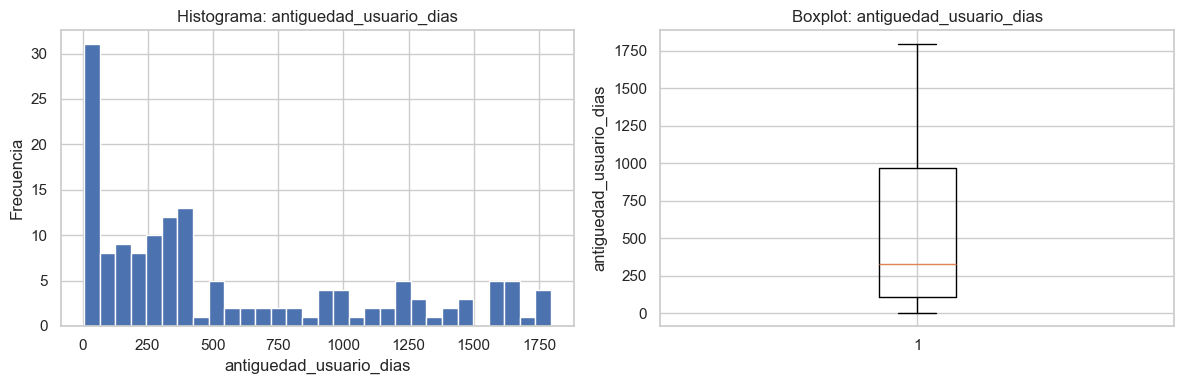

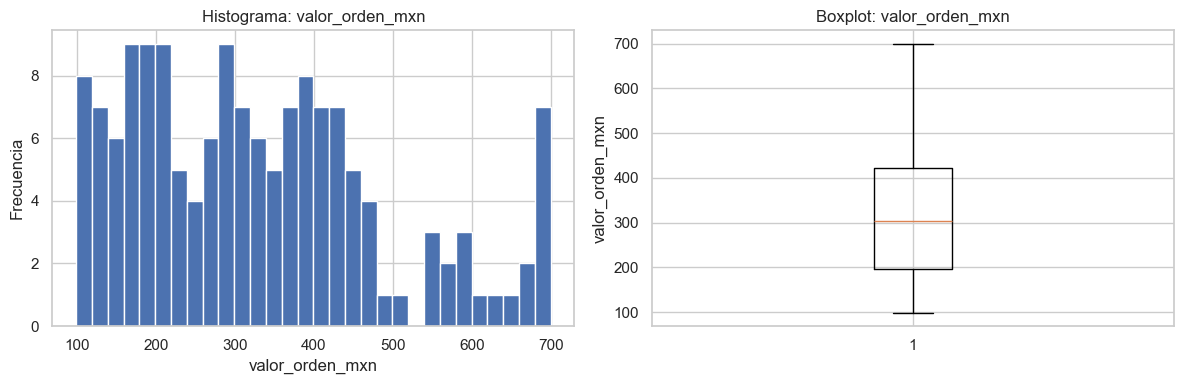

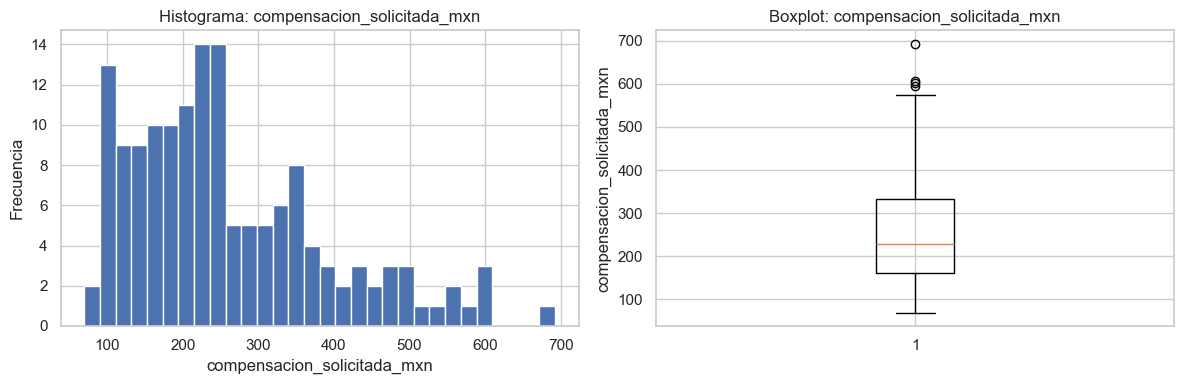

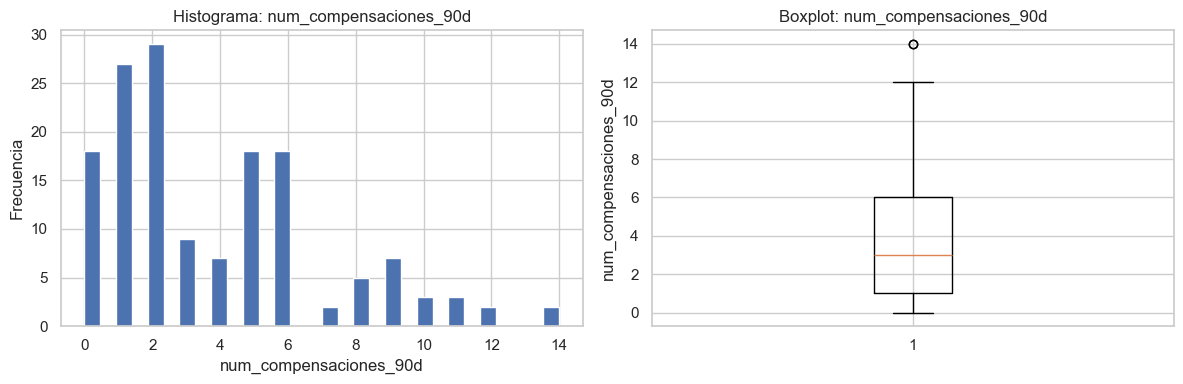

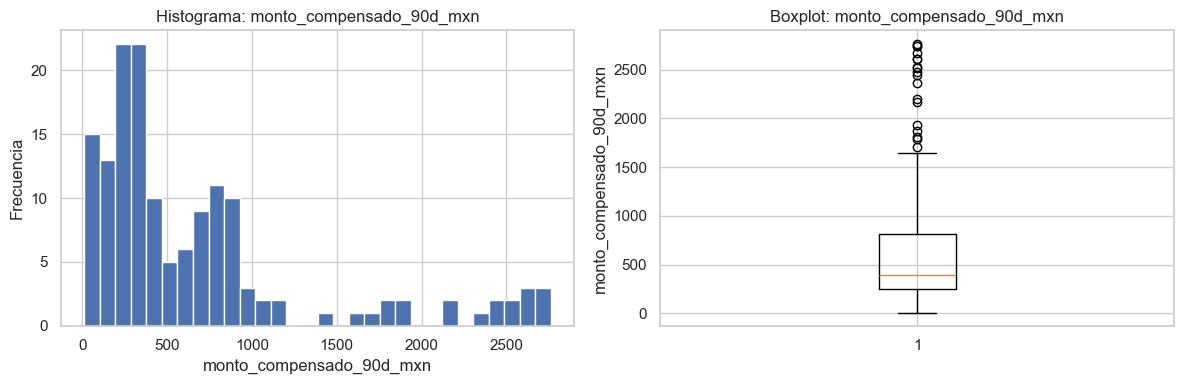

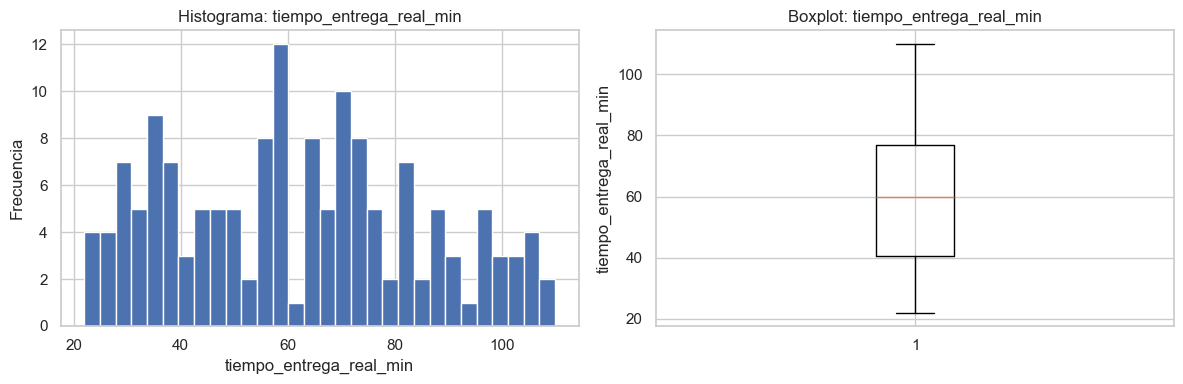

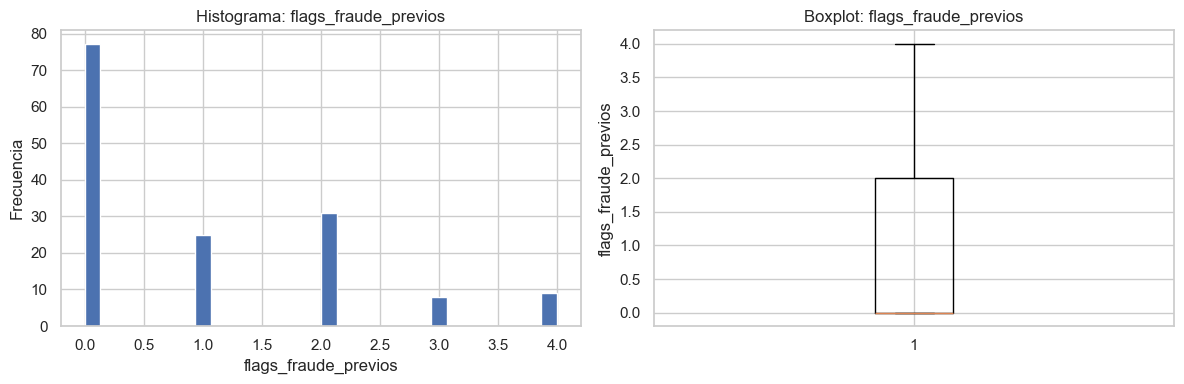

In [6]:
numericas = df.select_dtypes(include='number').columns.tolist()

for var in numericas:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df[var].dropna(), bins=30, color='#4C72B0', edgecolor='white')
    axes[0].set_title(f'Histograma: {var}')
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Frecuencia')

    axes[1].boxplot(df[var].dropna(), vert=True)
    axes[1].set_title(f'Boxplot: {var}')
    axes[1].set_ylabel(var)

    fig.tight_layout()
    plt.show()

### Detección de outliers por IQR

Cuantificamos los outliers visibles con la regla clásica: valores por encima de `Q3 + 1.5 × IQR`. Estos umbrales complementan a los percentiles para definir las reglas de RECHAZAR.

In [7]:
for var in numericas:
    q1, q3 = df[var].quantile([0.25, 0.75])
    iqr = q3 - q1
    techo = q3 + 1.5 * iqr
    n_out = int((df[var] > techo).sum())
    if n_out > 0:
        print(f'{var}: {n_out} outliers por encima de {techo:,.2f}')

compensacion_solicitada_mxn: 4 outliers por encima de 589.29
num_compensaciones_90d: 2 outliers por encima de 13.50
monto_compensado_90d_mxn: 18 outliers por encima de 1,650.63


### Lectura de distribuciones

- **`monto_compensado_90d_mxn`** tiene 18 outliers (> 1,650 MXN): hay una sub-población de usuarios que acumula compensaciones muy por encima del resto — señal fuerte de abuso recurrente.
- **`compensacion_solicitada_mxn`** tiene solo 4 outliers (> 589 MXN): los montos extremos individuales son raros, pero existen.
- **`num_compensaciones_90d`** tiene 2 outliers (> 13.5): reclamar más de 13 veces en 90 días es excepcional.

## 6. Correlaciones

Matriz de Pearson entre variables numéricas. Nos interesa:

- Si `compensacion_solicitada_mxn` se mueve con `valor_orden_mxn` (lo razonable) — las **desviaciones** de esa relación son sospechosas.
- Si `num_compensaciones_90d` se asocia a `flags_fraude_previos` (validación de que la frecuencia es una señal de riesgo real).

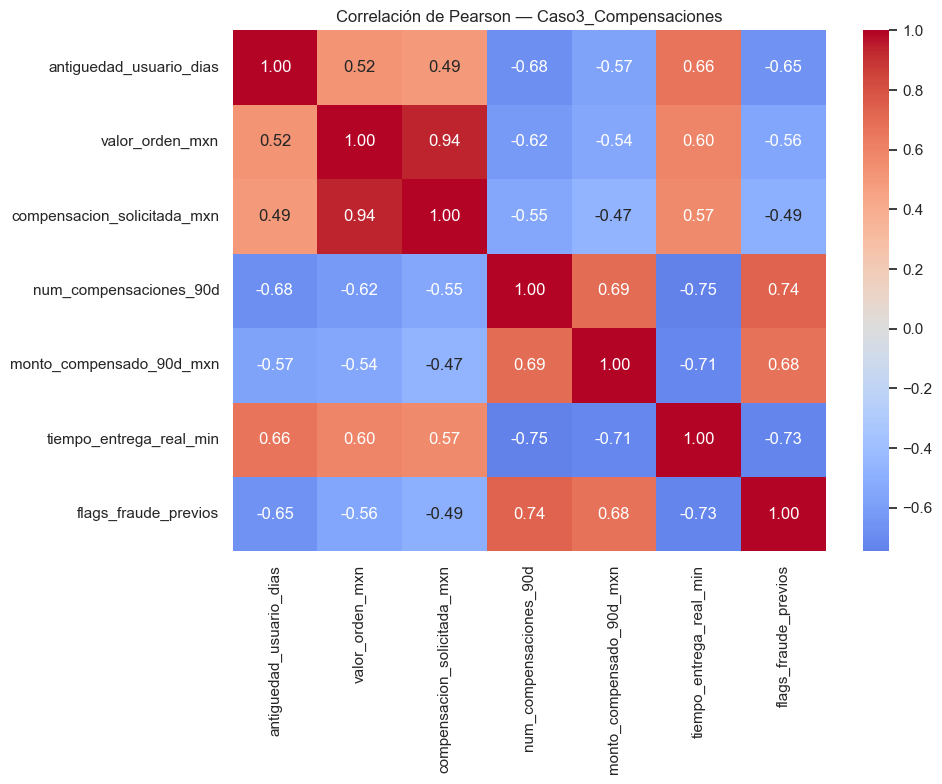

In [8]:
corr = df.select_dtypes(include='number').corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlación de Pearson — Caso3_Compensaciones')
fig.tight_layout()
plt.show()

In [9]:
pares = corr.unstack()
pares = pares[pares.index.get_level_values(0) != pares.index.get_level_values(1)]
pares = pares[abs(pares) < 1.0].drop_duplicates().sort_values(
    key=abs, ascending=False
)
print('Top-5 correlaciones más fuertes:')
for (a, b), r in pares.head(5).items():
    print(f'  {a} vs {b}: r = {r:.3f}')

Top-5 correlaciones más fuertes:
  valor_orden_mxn vs compensacion_solicitada_mxn: r = 0.941
  num_compensaciones_90d vs tiempo_entrega_real_min: r = -0.746
  num_compensaciones_90d vs flags_fraude_previos: r = 0.740
  tiempo_entrega_real_min vs flags_fraude_previos: r = -0.732
  monto_compensado_90d_mxn vs tiempo_entrega_real_min: r = -0.715


### Lectura de correlaciones

- **`valor_orden_mxn` vs `compensacion_solicitada_mxn`: r = 0.94.** Relación casi lineal esperable (pides compensación proporcional a tu orden). **Implicación:** el ratio compensación/orden (`comp_ratio`) es una señal útil: quien se desvía de esa proporción es atípico.
- **`num_compensaciones_90d` vs `flags_fraude_previos`: r = 0.74.** La frecuencia de reclamos se asocia con flags de fraude: valida usarla como señal.
- **Correlaciones negativas** de `tiempo_entrega_real_min` con reclamos y flags: quien más reclama reporta entregas más rápidas (patrón contraintuitivo, posible indicador de reclamos oportunistas).

## 7. Patrones de negocio

### 7.1 Geografía y vertical

Volumen de casos por ciudad y vertical, y compensación media por vertical. Sirve para detectar concentraciones geográficas anómalas y calibrar si alguna vertical reclama sistemáticamente más.

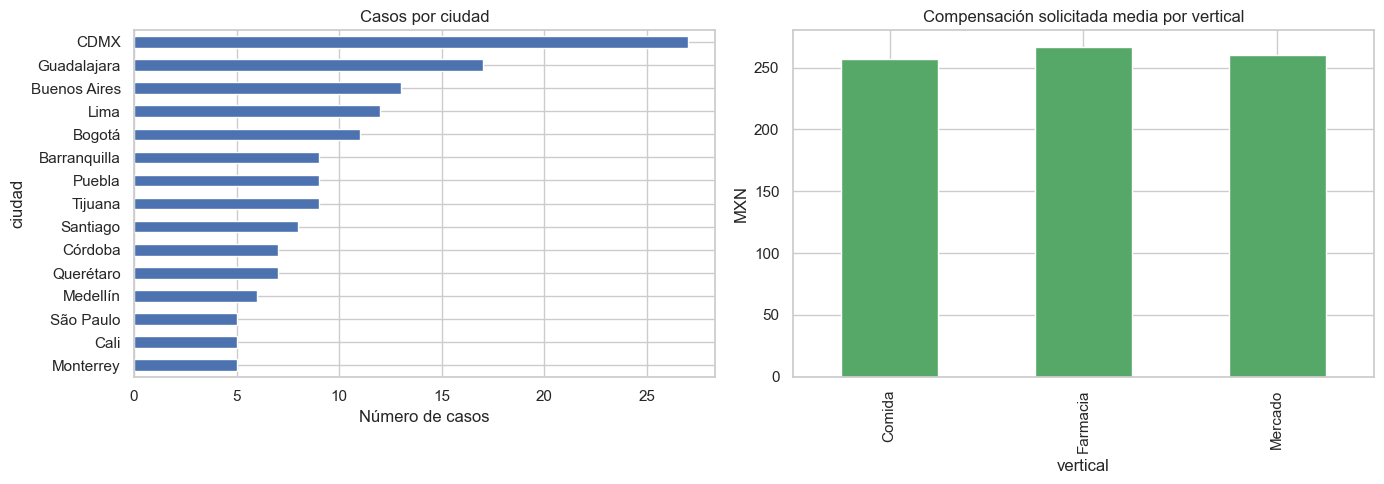

Casos por vertical:
vertical
Comida      79
Mercado     38
Farmacia    33


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ciudad'].value_counts().sort_values().plot.barh(
    ax=axes[0], color='#4C72B0'
)
axes[0].set_title('Casos por ciudad')
axes[0].set_xlabel('Número de casos')

df.groupby('vertical')['compensacion_solicitada_mxn'].mean().plot.bar(
    ax=axes[1], color='#55A868'
)
axes[1].set_title('Compensación solicitada media por vertical')
axes[1].set_ylabel('MXN')

fig.tight_layout()
plt.show()

print('Casos por vertical:')
print(df['vertical'].value_counts().to_string())

#### Lectura

- **Comida** concentra 79 de 150 casos (53%) — esperable por ser la vertical con más volumen de órdenes.
- Las compensaciones medias son similares entre verticales (~257-267 MXN): ninguna vertical reclama sistemáticamente más, así que no requiere threshold propio.

### 7.2 Restaurantes con más reclamos

Si un restaurante concentra muchos reclamos, puede indicar problema operativo real (no fraude del usuario) o un vector de fraude organizado. Se calcula también su peso relativo sobre el total.

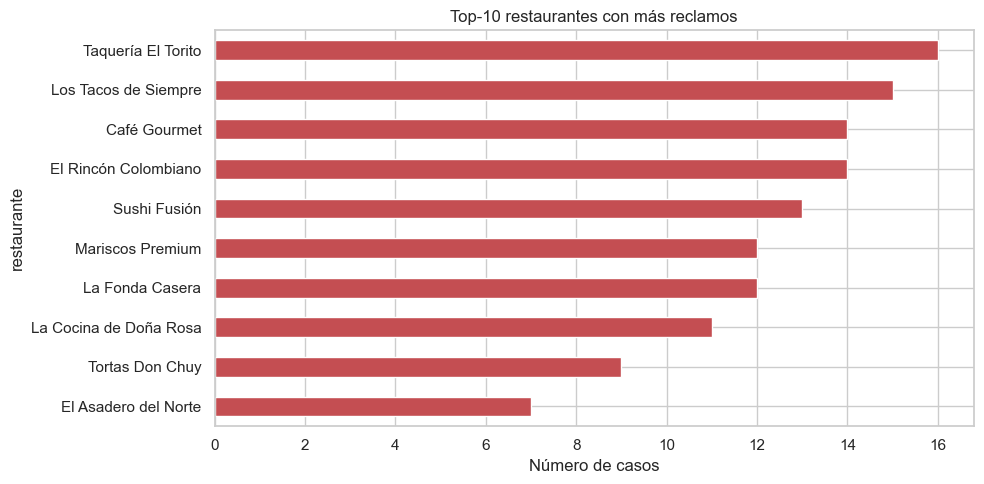

Participación sobre 150 casos:
restaurante
Taquería El Torito        10.7%
Los Tacos de Siempre      10.0%
El Rincón Colombiano       9.3%
Café Gourmet               9.3%
Sushi Fusión               8.7%
La Fonda Casera            8.0%
Mariscos Premium           8.0%
La Cocina de Doña Rosa     7.3%
Tortas Don Chuy            6.0%
El Asadero del Norte       4.7%
Name: count, dtype: str


In [11]:
top_rest = df['restaurante'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_rest.sort_values().plot.barh(ax=ax, color='#C44E52')
ax.set_title('Top-10 restaurantes con más reclamos')
ax.set_xlabel('Número de casos')
fig.tight_layout()
plt.show()

print('Participación sobre 150 casos:')
print((top_rest / len(df) * 100).round(1).astype(str) + '%')

#### Lectura

- Los 10 restaurantes con más reclamos suman ~123 de 150 casos: la concentración es alta pero el dataset es pequeño, así que el riesgo por restaurante se usará como feature **agregado suave**, no como regla dura.

### 7.3 Antigüedad del usuario

Hipótesis: **los usuarios nuevos reclaman más y acumulan más flags de fraude**. Agrupamos en buckets (0-30d, 31-90d, 91-365d, 365d+) y comparamos la media de reclamos en 90 días y de flags previos.

                   casos  comps_90d_media  flags_media
bucket_antiguedad                                     
0-30d                 23             8.57         2.83
31-90d                11             7.91         2.27
91-365d               44             4.02         0.95
365d+                 72             1.51         0.21


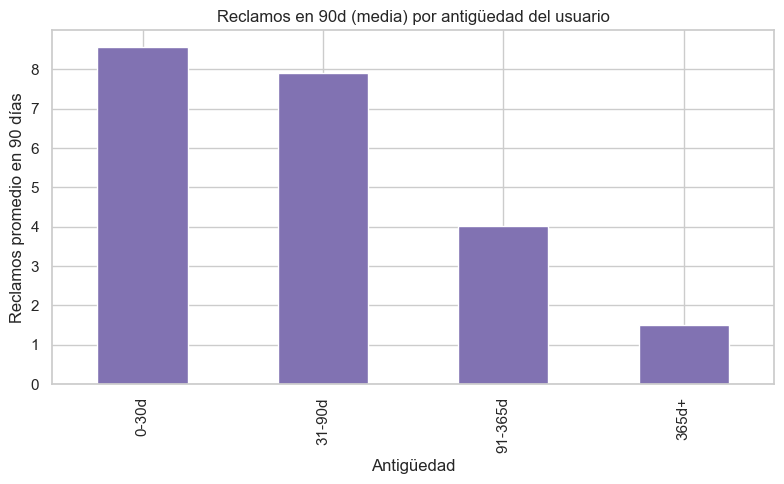

In [12]:
df['bucket_antiguedad'] = pd.cut(
    df['antiguedad_usuario_dias'],
    bins=[0, 30, 90, 365, float('inf')],
    labels=['0-30d', '31-90d', '91-365d', '365d+'],
)

resumen_antiguedad = df.groupby('bucket_antiguedad', observed=True).agg(
    casos=('caso_id', 'count'),
    comps_90d_media=('num_compensaciones_90d', 'mean'),
    flags_media=('flags_fraude_previos', 'mean'),
)
print(resumen_antiguedad.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
resumen_antiguedad['comps_90d_media'].plot.bar(ax=ax, color='#8172B2')
ax.set_title('Reclamos en 90d (media) por antigüedad del usuario')
ax.set_ylabel('Reclamos promedio en 90 días')
ax.set_xlabel('Antigüedad')
fig.tight_layout()
plt.show()

#### Lectura — insight fuerte

- **Usuarios de 0-30 días: media de 8.6 reclamos/90d y 2.8 flags de fraude.**
- **Usuarios de 365+ días: media de 1.5 reclamos/90d y 0.2 flags.**

La antigüedad es el predictor más claro del dataset: a menor antigüedad, mayor frecuencia de reclamos y más flags previos. Debe ponderar fuerte en las reglas.

### 7.4 GPS vs frecuencia de reclamos

Hipótesis inicial: *GPS no confirmado → reclamo sospechoso*. Verificamos si los datos la soportan cruzando el estado GPS con reclamos, flags y monto medio.

                        casos  comps_90d_media  flags_media  comp_media
entrega_confirmada_gps                                                 
NO confirmada              54             1.94         0.31      328.41
Parcial                    18             3.83         1.11      206.16
Señal perdida              35             2.00         0.34      304.03
SÍ - confirmada            43             7.58         2.28      160.99


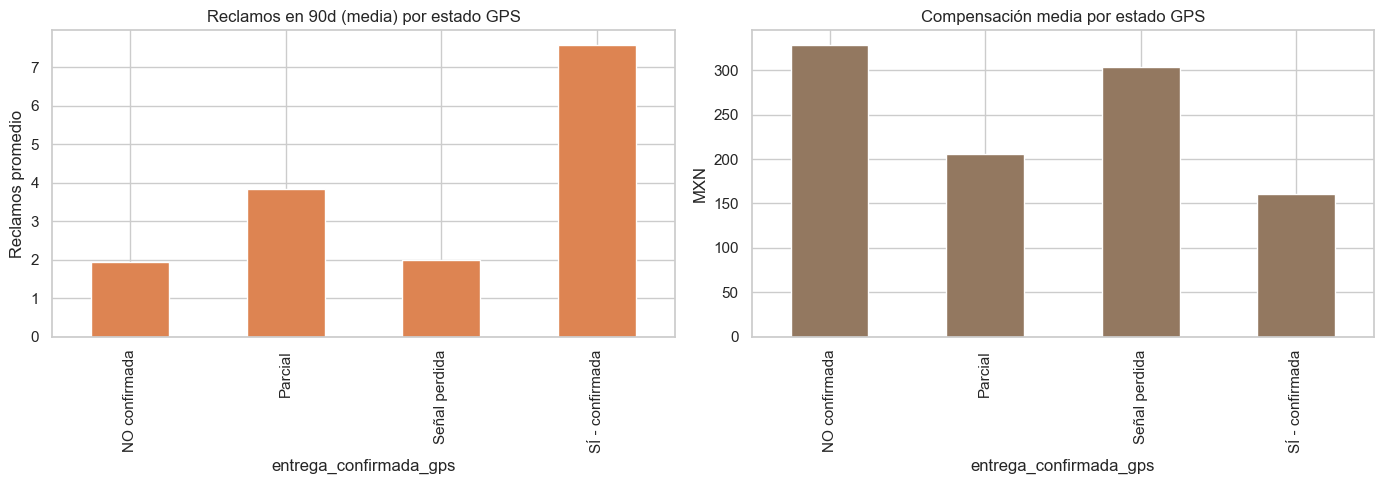

In [13]:
resumen_gps = df.groupby('entrega_confirmada_gps').agg(
    casos=('caso_id', 'count'),
    comps_90d_media=('num_compensaciones_90d', 'mean'),
    flags_media=('flags_fraude_previos', 'mean'),
    comp_media=('compensacion_solicitada_mxn', 'mean'),
)
print(resumen_gps.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_gps['comps_90d_media'].plot.bar(ax=axes[0], color='#DD8452')
axes[0].set_title('Reclamos en 90d (media) por estado GPS')
axes[0].set_ylabel('Reclamos promedio')

resumen_gps['comp_media'].plot.bar(ax=axes[1], color='#937860')
axes[1].set_title('Compensación media por estado GPS')
axes[1].set_ylabel('MXN')

fig.tight_layout()
plt.show()

#### Lectura — la paradoja del GPS

- Los casos con GPS **NO confirmada** piden compensaciones **altas** (~328 MXN) pero tienen pocos reclamos y pocos flags.
- Los casos con GPS **confirmada** piden compensaciones **bajas** (~161 MXN) pero concentran la mayor frecuencia de reclamos (7.6) y flags (2.3).

**Conclusión:** el GPS por sí solo NO decide. El defraudador sofisticado reclama montos pequeños y repetidos incluso con entrega confirmada. El GPS funciona como señal **en combinación** (ej. GPS no confirmada + monto alto + usuario nuevo), no aislada.

## 8. Conclusiones: señales candidatas para el motor de reglas

Insumos para el step 02 (feature engineering) y step 03 (reglas heurísticas):

| Señal (feature) | Evidencia del EDA | Uso propuesto |
|---|---|---|
| `comp_ratio` = compensación / valor_orden | r = 0.94 entre ambas; desviarse es atípico | RECHAZAR si > 2.0 |
| `antiguedad_usuario_dias` (baja) | 0-30d: 8.6 reclamos y 2.8 flags de media | Peso fuerte en scoring |
| `num_compensaciones_90d` | p95 = 10; correlación 0.74 con flags | RECHAZAR si > p95 |
| `monto_compensado_90d_mxn` | 18 outliers > 1,650 MXN | Score de riesgo acumulado |
| `flags_fraude_previos` | Predictor directo validado | RECHAZAR si ≥ 2 |
| `gps_match_ok` + monto alto | Paradoja GPS: no decide solo | Señal combinada, no aislada |
| `tiempo_entrega_real_min` | p90 = 96 min; correlación negativa con reclamos | Contexto, señal débil |
| `riesgo_restaurante` (agregado) | Concentración alta en pocos restaurantes | Feature suave |
| `descripcion_reclamo` (texto) | 23 textos únicos | Análisis LLM en el pipeline |

**Decisión de diseño:** con 150 casos no se entrena modelo ML. El motor será de **reglas heurísticas** con thresholds derivados de los percentiles aquí calculados (centralizados en `src/rules/thresholds.yaml`), más análisis LLM del texto libre para los casos que las reglas no resuelvan → **ESCALAR**.